**Test segmentation on U-net**

# Connect google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# You can choose any image from your validation set or another test set.
TEST_IMAGE_PATH = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/test_images/83_HC.png' # Example path
model_save_path = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Model_weights/segmentation_Unet_model.pth'

In [3]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

import os
import cv2
import numpy as np
from skimage.color import rgb2lab, lab2rgb
import matplotlib.pyplot as plt

import torch
import matplotlib.pyplot as plt
import numpy as np

# Model

In [4]:
class Unet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(Unet, self).__init__()

        # Reduced dropout from 0.5 to 0.1/0.2 to help validation stability
        # Using Dropout2d is often better for spatial feature maps
        drop_rate = 0.1

        # --- ENCODER (Downsampling) ---
        self.conv1_1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv1_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool1 = nn.MaxPool2d(2)
        self.conv2_1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv2_2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool2 = nn.MaxPool2d(2)
        self.conv3_1 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv3_2 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool3 = nn.MaxPool2d(2)
        self.conv4_1 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv4_2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool4 = nn.MaxPool2d(2)
        self.conv5_1 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv5_2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        # --- DECODER (Upsampling) ---
        self.upconv1 = nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2)
        self.uconv1_1 = nn.Sequential(
            nn.Conv2d(1024, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv1_2 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.upconv2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.uconv2_1 = nn.Sequential(
            nn.Conv2d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv2_2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.upconv3 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.uconv3_1 = nn.Sequential(
            nn.Conv2d(256, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv3_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.upconv4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.uconv4_1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv4_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        # FINAL OUTPUT: Sigmoid forces values into [0, 1] range for segmentation
        self.final = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        xin = self.conv1_1(x)
        xin = self.conv1_2(xin) + xin

        xd1 = self.pool1(xin)
        xd1 = self.conv2_1(xd1)
        xd1 = self.conv2_2(xd1) + xd1

        xd2 = self.pool2(xd1)
        xd2 = self.conv3_1(xd2)
        xd2 = self.conv3_2(xd2) + xd2

        xd3 = self.pool3(xd2)
        xd3 = self.conv4_1(xd3)
        xd3 = self.conv4_2(xd3) + xd3

        xd4 = self.pool4(xd3)
        xd4 = self.conv5_1(xd4)
        xd4 = self.conv5_2(xd4) + xd4

        # Decoder
        xu1_up = self.upconv1(xd4)
        diffY, diffX = xd3.size()[2] - xu1_up.size()[2], xd3.size()[3] - xu1_up.size()[3]
        xu1_up = F.pad(xu1_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu1 = torch.cat([xd3, xu1_up], dim=1)
        xu1_pre = self.uconv1_1(xu1)
        xu1 = self.uconv1_2(xu1_pre) + xu1_pre

        xu2_up = self.upconv2(xu1)
        diffY, diffX = xd2.size()[2] - xu2_up.size()[2], xd2.size()[3] - xu2_up.size()[3]
        xu2_up = F.pad(xu2_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu2 = torch.cat([xd2, xu2_up], dim=1)
        xu2_pre = self.uconv2_1(xu2)
        xu2 = self.uconv2_2(xu2_pre) + xu2_pre

        xu3_up = self.upconv3(xu2)
        diffY, diffX = xd1.size()[2] - xu3_up.size()[2], xd1.size()[3] - xu3_up.size()[3]
        xu3_up = F.pad(xu3_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu3 = torch.cat([xd1, xu3_up], dim=1)
        xu3_pre = self.uconv3_1(xu3)
        xu3 = self.uconv3_2(xu3_pre) + xu3_pre

        xu4_up = self.upconv4(xu3)
        diffY, diffX = xin.size()[2] - xu4_up.size()[2], xin.size()[3] - xu4_up.size()[3]
        xu4_up = F.pad(xu4_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu4 = torch.cat([xin, xu4_up], dim=1)
        xu4_pre = self.uconv4_1(xu4)
        xu4 = self.uconv4_2(xu4_pre) + xu4_pre

        return self.final(xu4)

# Preprocess input image

In [5]:
# --- Image Preprocessing for a single image ---
def preprocess_image_for_inference(image_path, image_size=256):
    img_rgb = cv2.imread(image_path)
    if img_rgb is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    img_rgb_resized = cv2.resize(img_rgb, (image_size, image_size))

    # Convert to LAB and extract L channel
    lab_img = rgb2lab(img_rgb_resized).astype(np.float32)
    l_channel = lab_img[:, :, 0] / 100.0  # Normalize L to [0, 1]

    # Convert to PyTorch tensor and add batch dimension (B, C, H, W)
    input_tensor = torch.from_numpy(l_channel).float().unsqueeze(0).unsqueeze(0)

    return input_tensor, lab_img[:, :, 0] # Return original L for display and the processed input

# Load and preprocess the test image
test_input_tensor, original_l_channel_for_display = preprocess_image_for_inference(TEST_IMAGE_PATH)

print(f"Preprocessed input tensor shape: {test_input_tensor.shape}")

Preprocessed input tensor shape: torch.Size([1, 1, 256, 256])


# Model Evaluation

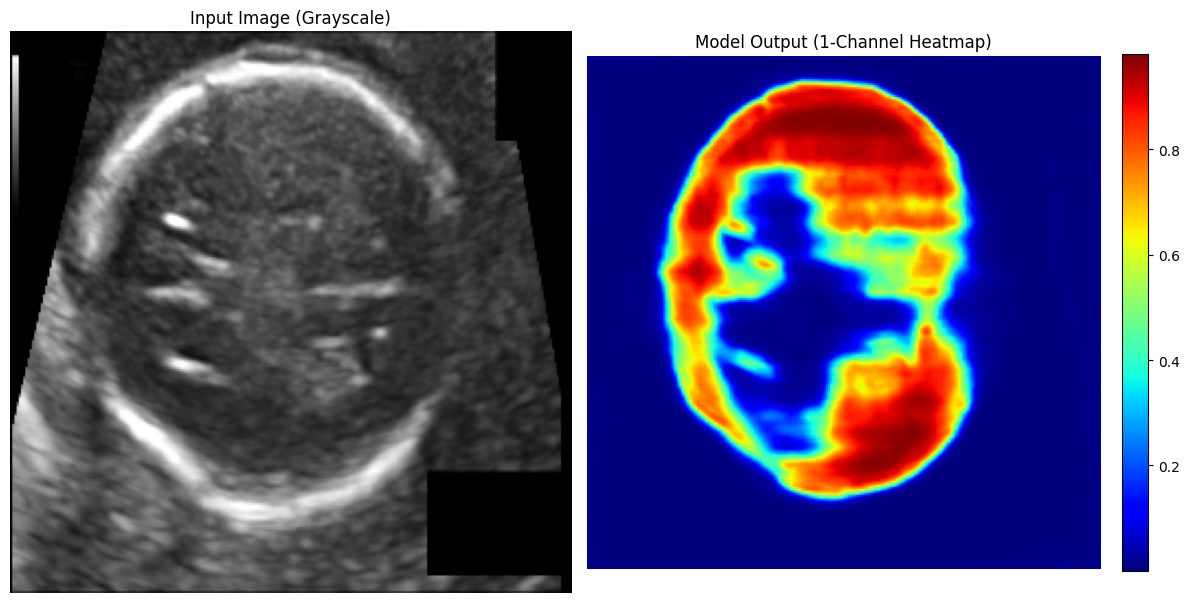

In [6]:
# 1. Path and Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load the Model State
# Assuming 'model' and 'optimizer' are already defined in your script
checkpoint = torch.load(model_save_path, map_location=device)
model = Unet(in_channels=1, out_channels=1).to(device)

# Handle different checkpoint formats (check if it's a dict or just the state_dict)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

# 3. Perform Inference
# Ensure input is (Batch, Channel, H, W) -> e.g., (1, 1, H, W)
test_input_tensor = test_input_tensor.to(device)

with torch.no_grad():
    output_tensor = model(test_input_tensor)

    # If this is binary segmentation, apply sigmoid to get values between 0 and 1
    # output_tensor = torch.sigmoid(output_tensor)

# 4. Post-processing
# Move to CPU and remove dimensions to get a 2D (H, W) array
output_np = output_tensor.cpu().squeeze().numpy()
input_np = test_input_tensor.cpu().squeeze().numpy()

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the Input
axes[0].imshow(input_np, cmap='gray')
axes[0].set_title('Input Image (Grayscale)')
axes[0].axis('off')

# Display 1-Channel Output using a Colormap
# 'viridis' or 'magma' are great for visibility; 'gray' is standard for masks
im = axes[1].imshow(output_np, cmap='jet')
axes[1].set_title('Model Output (1-Channel Heatmap)')
axes[1].axis('off')

# Add a colorbar to show intensity values
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

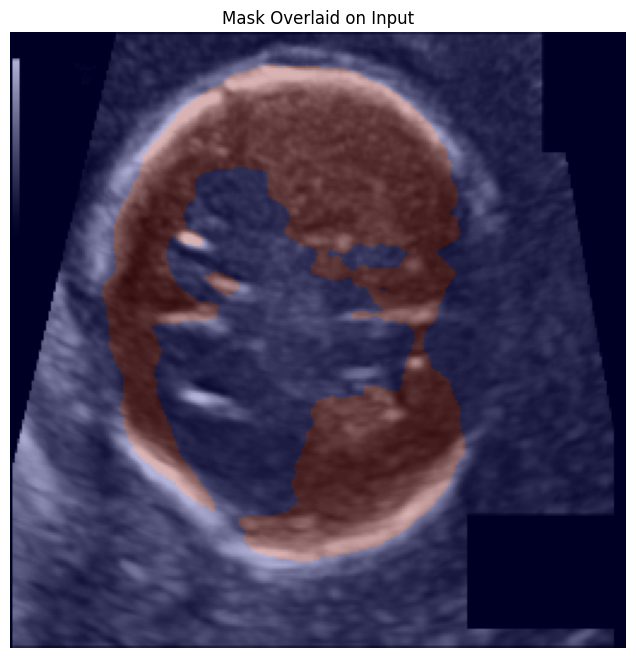

In [7]:
# --- 4. Post-processing (Updated for Overlay) ---
# Assuming binary segmentation: threshold the output to get a 0/1 mask
threshold = 0.5
# If your model doesn't have a final sigmoid, use: torch.sigmoid(output_tensor)
mask_np = (output_tensor.cpu().squeeze() > threshold).numpy().astype(np.uint8)
input_np = test_input_tensor.cpu().squeeze().numpy()

# --- 5. Visualization (Overlay) ---
plt.figure(figsize=(8, 8))
plt.imshow(input_np, cmap='gray') # Base image
plt.imshow(mask_np, cmap='jet', alpha=0.3) # Overlay mask with 30% opacity
plt.title('Mask Overlaid on Input')
plt.axis('off')
plt.show()

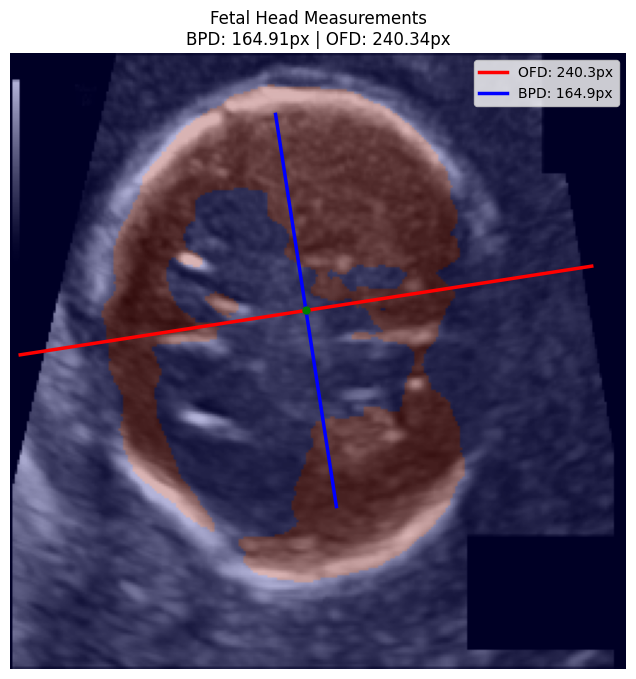

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.measure import label, regionprops

# 1. Process the mask
label_img = label(mask_np)
props = regionprops(label_img)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(input_np, cmap='gray')
ax.imshow(mask_np, cmap='jet', alpha=0.3) # Overlay mask

if len(props) > 0:
    # Get the largest object
    obj = max(props, key=lambda x: x.area)
    y0, x0 = obj.centroid
    orientation = obj.orientation
    major_axis = obj.major_axis_length
    minor_axis = obj.minor_axis_length

    # --- Calculate OFD Line (Major Axis) ---
    x1 = x0 + math.cos(orientation) * 0.5 * major_axis
    y1 = y0 - math.sin(orientation) * 0.5 * major_axis
    x2 = x0 - math.cos(orientation) * 0.5 * major_axis
    y2 = y0 + math.sin(orientation) * 0.5 * major_axis

    # --- Calculate BPD Line (Minor Axis) ---
    x3 = x0 + math.sin(orientation) * 0.5 * minor_axis
    y3 = y0 + math.cos(orientation) * 0.5 * minor_axis
    x4 = x0 - math.sin(orientation) * 0.5 * minor_axis
    y4 = y0 - math.cos(orientation) * 0.5 * minor_axis

    # 2. Draw the lines
    ax.plot((x1, x2), (y1, y2), '-r', linewidth=2.5, label=f'OFD: {major_axis:.1f}px')
    ax.plot((x3, x4), (y3, y4), '-b', linewidth=2.5, label=f'BPD: {minor_axis:.1f}px')

    # Plot the centroid
    ax.plot(x0, y0, '.g', markersize=10)

    ax.legend(loc='upper right')
    ax.set_title(f"Fetal Head Measurements\nBPD: {minor_axis:.2f}px | OFD: {major_axis:.2f}px")
else:
    ax.set_title("No Head Detected")

ax.axis('off')
plt.show()